In [1]:
from getdist import loadMCSamples
import getdist.plots as plots
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [ ]:
class CobayaAnalyzer:
    def __init__(self, chain_dicts, burn_in=0.3):
        self.chains = chain_dicts.copy()
        self.burn_in = burn_in
        self._load_chains()
        self._setup_publication_style()
    def _load_chains(self):
        print(f"Loading chains")
        for experiment, [chain_path, _, _] in self.chains.items():
            try:
                self.chains[experiment][0] = loadMCSamples(chain_path, settings={'ignore_rows': self.burn_in,
                                                             'smooth_scale_1D': -1, 
                                                             'smooth_scale_2D': -1})
                self.chains[experiment][0].getParamNames().parWithName('omega_b').label = r'\Omega_{\rm b} h^2'
            except Exception as e:
                print(f" -> Error loading {experiment}: {e}")
    def _setup_publication_style(self):
        plt.rcParams['text.usetex'] = False 
        plt.rcParams['mathtext.fontset'] = 'cm' 
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']

    def plot_triangle(self, params, colors=None, fontsize=None, save_as=None, legend_labels=None):
        plot_settings = plots.GetDistPlotSettings()

        # Adjust Font Sizes
        plot_settings.axes_fontsize = fontsize[0]     # Tick numbers
        plot_settings.lab_fontsize = fontsize[1]      # Axis labels (x, y)
        plot_settings.legend_fontsize = fontsize[2]   # Legend text

        # Visual Tweaks for Publications
        plot_settings.figure_legend_frame = False  # Removes the box around the legend
        plot_settings.alpha_filled_add = 0.75      # Adjust transparency of filled contours

        g = plots.get_subplot_plotter(settings=plot_settings)

        sample_list = []
        dataset_list = []
        for list in self.chains.values():
            sample_list.append(list[0])
            dataset_list.append(list[1])
        if legend_labels is None:
            legend_labels = dataset_list
        g.triangle_plot(roots=sample_list, 
                        params=params, 
                        legend_labels=legend_labels, 
                        filled=True, 
                        contour_colors=colors,
                        contour_ls='-',
                        contour_lws=1.5)
        if save_as:
            g.export(f'figure/triangle_plot_{save_as}.pdf')


In [12]:
chains = {}
models = {}
chain_dir = Path(r'/home/theppawan/cosmo-research/quintom-project/chains')
chain_prefixes = [p.with_suffix('') for p in chain_dir.rglob('*.checkpoint')]

for prefix_path in chain_prefixes:
    chain_name = prefix_path.name
    model, dataset = chain_name.split("_", 1)

    # Set model label
    if 'lcdm' in model:
        models_label = r'\Lambda {\rm CDM}'
    else:
        models_label = model.capitalize()
    models[model] = models_label

    # Set dataset label
    if 'theta' in dataset:
        label = dataset.replace("theta", r"$\theta_*$")
    else:
        label = dataset
    chains[chain_name] = [str(prefix_path), rf"{label}", models_label]

# Sub-Dictionary
lcdm_chains = {key: chains[key] for key in chains.keys() if 'lcdm' in key}
quintom_chains = {key: chains[key] for key in chains.keys() if 'quintom' in key}

quintom_chains['quintom_DESI+CMB+SNIa'][0] += '_with_Mb'
quintom_chains['quintom_DESI+BBN+SNIa'][0] += '_with_Mb'

Loading chains
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB/quintom_DESI+CMB.1.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB/quintom_DESI+CMB.2.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB/quintom_DESI+CMB.3.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB/quintom_DESI+CMB.4.txt
Removed 0.3 as burn in
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB+SNIa/quintom_DESI+CMB+SNIa_with_Mb.txt
Removed 0.3 as burn in
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB+SNIa+SH0ES/quintom_DESI+CMB+SNIa+SH0ES.1.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB+SNIa+SH0ES/quintom_DESI+CMB+SNIa+SH0ES.2.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB+SNIa+SH0ES/quintom_DESI+CMB+SNIa+SH0ES.3.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+CMB+SNIa+SH0ES/quintom_DESI+CMB+SNIa+S

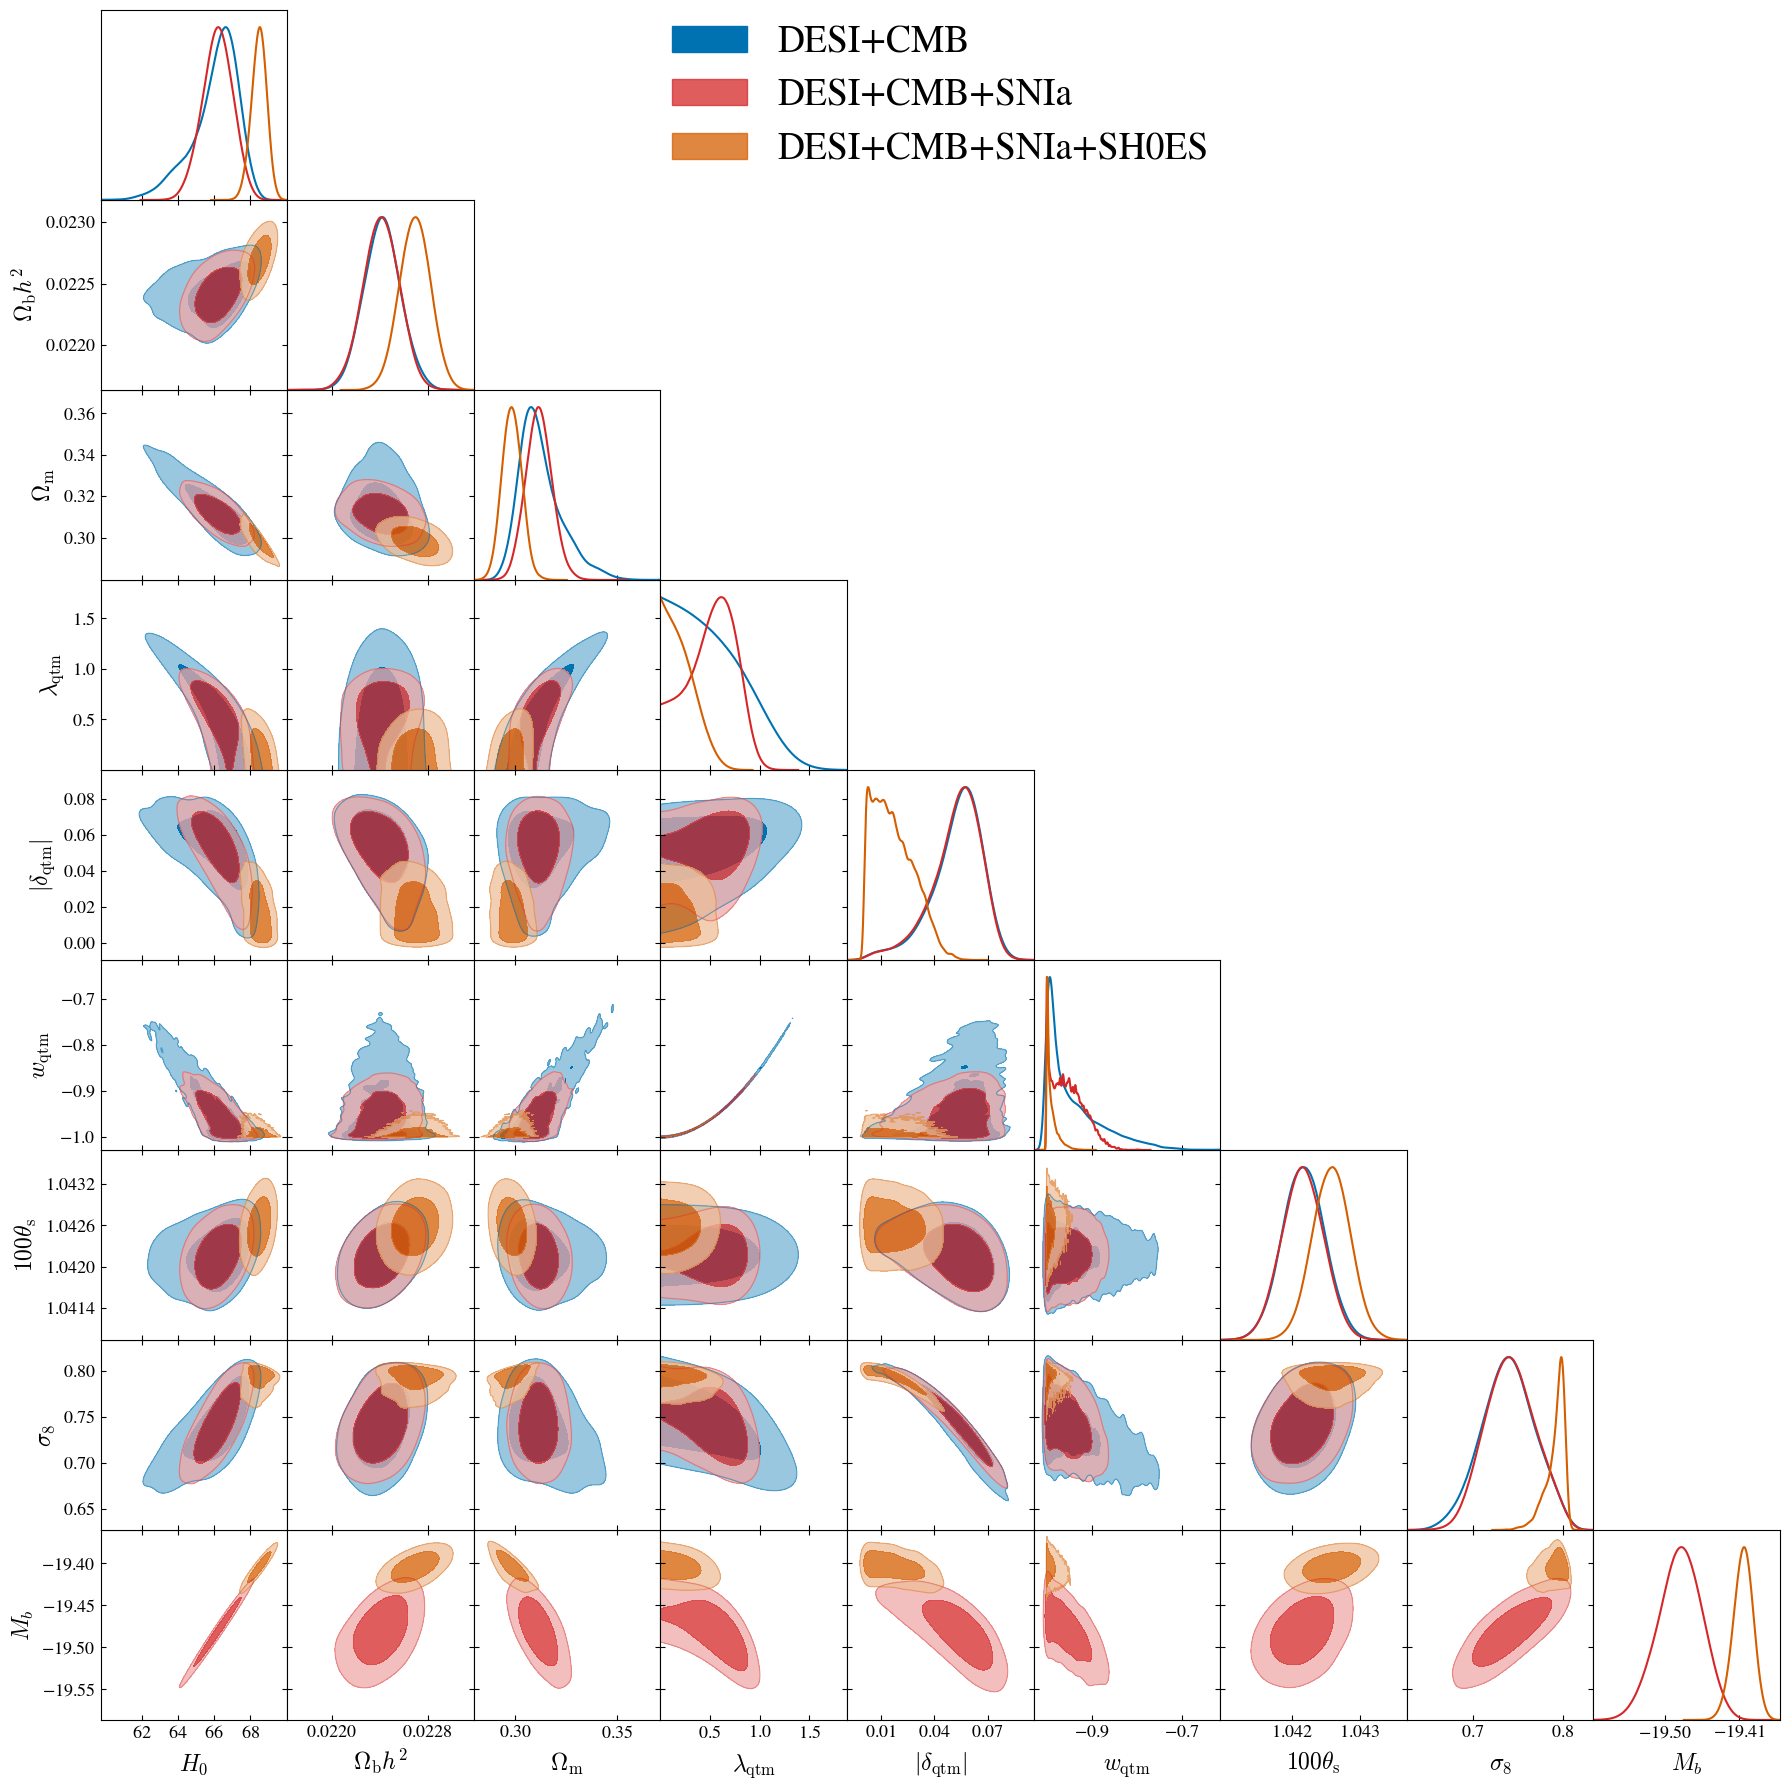

In [13]:
dataset_1 = ['CMB']
quintom_chains_1 = {key: chains[key] for key in chains.keys() if 'quintom' in key and any(ds in key for ds in dataset_1)}
sorted_quintom_chains_1 = {k: quintom_chains_1[k] for k in sorted(quintom_chains_1.keys(), key=len)}
quintom_plot_1 = CobayaAnalyzer(chain_dicts=sorted_quintom_chains_1, burn_in=0.3)
for _, [sample, _, _] in quintom_plot_1.chains.items():
    p = sample.getParams()
    try:
        if not sample.paramNames.parWithName('abs_delta_qtm'):
            abs_delta_qtm = np.abs(p.delta_qtm)
            sample.addDerived(abs_delta_qtm, name='abs_delta_qtm', label=r'|\delta_{\mathrm{qtm}}|')
    except AttributeError:
        print(f"Parameter 'delta_qtm' not found in sample: {sample.getName()}")
        continue

quintom_plot_1.plot_triangle(params=['H0', 'omega_b', 'Omega_m', 'lambda_qtm', 'abs_delta_qtm', 'w_qtm', 'theta_s_100', 'sigma8', 'Mb'],
                            fontsize=[16,20,30],
                            colors=['#0072B2','#D62728','#D55E00'],
                            save_as='quintom_1')

Loading chains
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa/quintom_DESI+BBN+SNIa_with_Mb.txt
Removed 0.3 as burn in
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa+SH0ES/quintom_DESI+BBN+SNIa+SH0ES.1.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa+SH0ES/quintom_DESI+BBN+SNIa+SH0ES.2.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa+SH0ES/quintom_DESI+BBN+SNIa+SH0ES.3.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa+SH0ES/quintom_DESI+BBN+SNIa+SH0ES.4.txt
Removed 0.3 as burn in


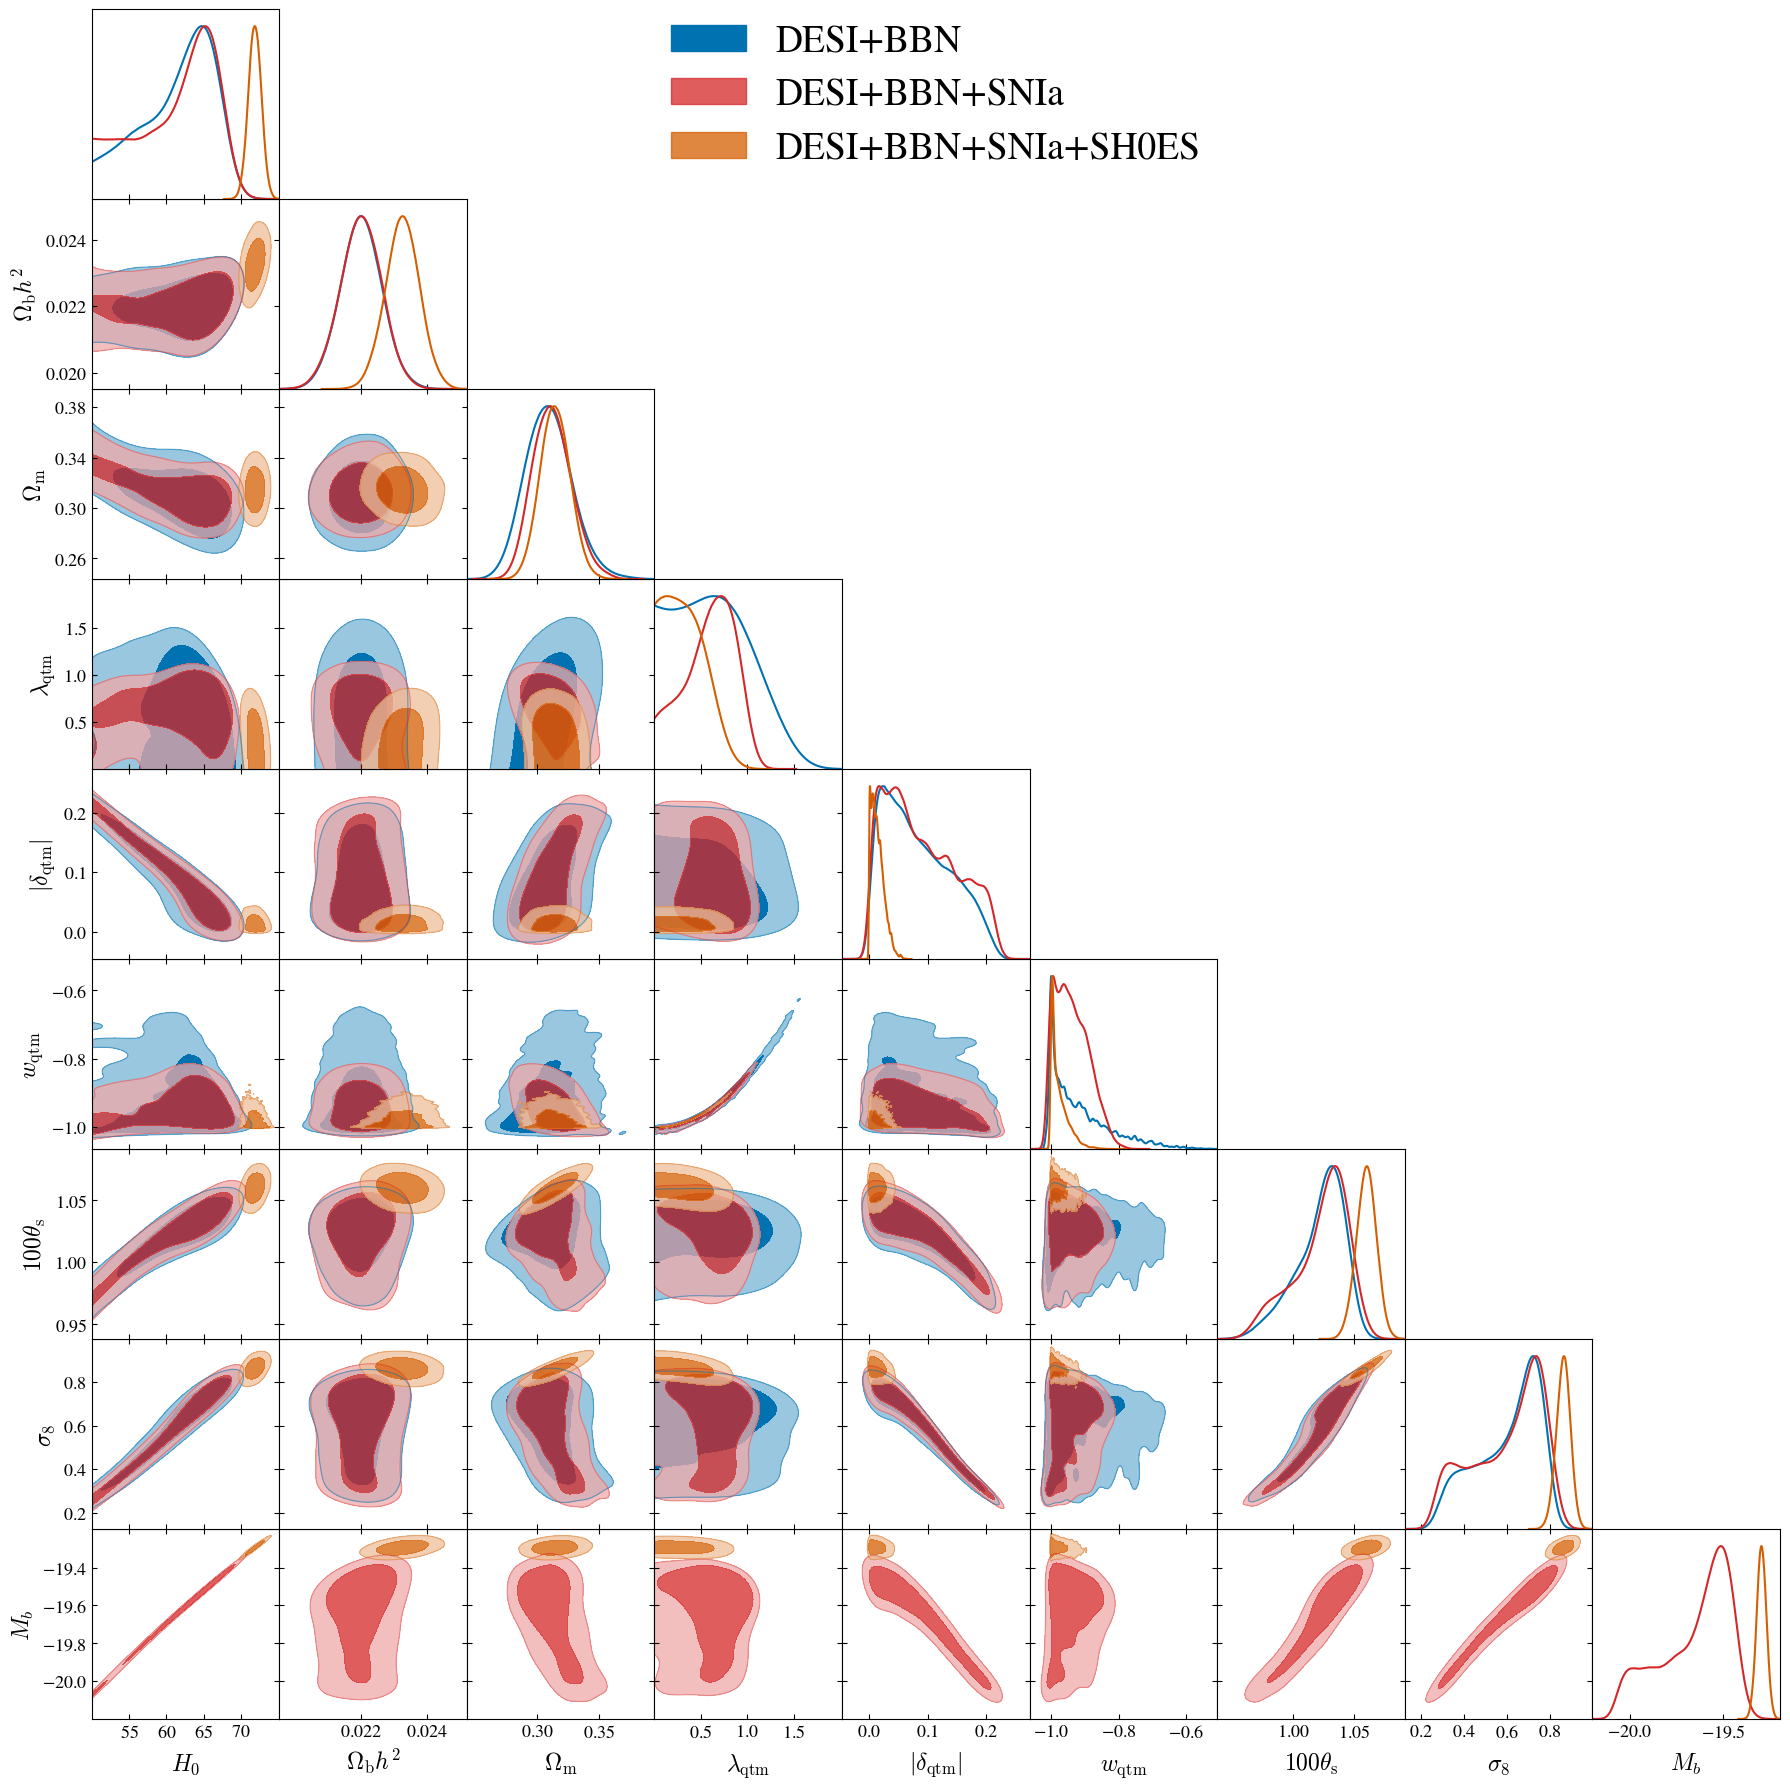

In [14]:
dataset_2 = ['BBN']
quintom_chains_2 = {key: chains[key] for key in chains.keys() if 'quintom' in key and any(ds in key for ds in dataset_2)}
sorted_quintom_chains_2 = {k: quintom_chains_2[k] for k in sorted(quintom_chains_2.keys(), key=len)}

quintom_plot_2 = []
quintom_plot_2 = CobayaAnalyzer(chain_dicts=sorted_quintom_chains_2, burn_in=0.3)
for _, [sample, _, _] in quintom_plot_2.chains.items():
    p = sample.getParams()
    try:
        if not sample.paramNames.parWithName('abs_delta_qtm'):
            abs_delta_qtm = np.abs(p.delta_qtm)
            sample.addDerived(abs_delta_qtm, name='abs_delta_qtm', label=r'|\delta_{\mathrm{qtm}}|')
    except AttributeError:
        print(f"Parameter 'delta_qtm' not found in sample: {sample.getName()}")
        continue

quintom_plot_2.plot_triangle(params=['H0', 'omega_b', 'Omega_m', 'lambda_qtm', 'abs_delta_qtm', 'w_qtm', 'theta_s_100', 'sigma8', 'Mb'],
                            fontsize=[16,20,30],
                            colors=['#0072B2', '#D62728', '#D55E00'],
                            save_as='quintom_2')

Loading chains
 -> Error loading lcdm_DESI+CMB+SNIa: expected str, bytes or os.PathLike object, not MCSamples
 -> Error loading quintom_DESI+CMB+SNIa: expected str, bytes or os.PathLike object, not MCSamples
Parameter 'delta_qtm' not found in sample: lcdm_DESI+CMB+SNIa


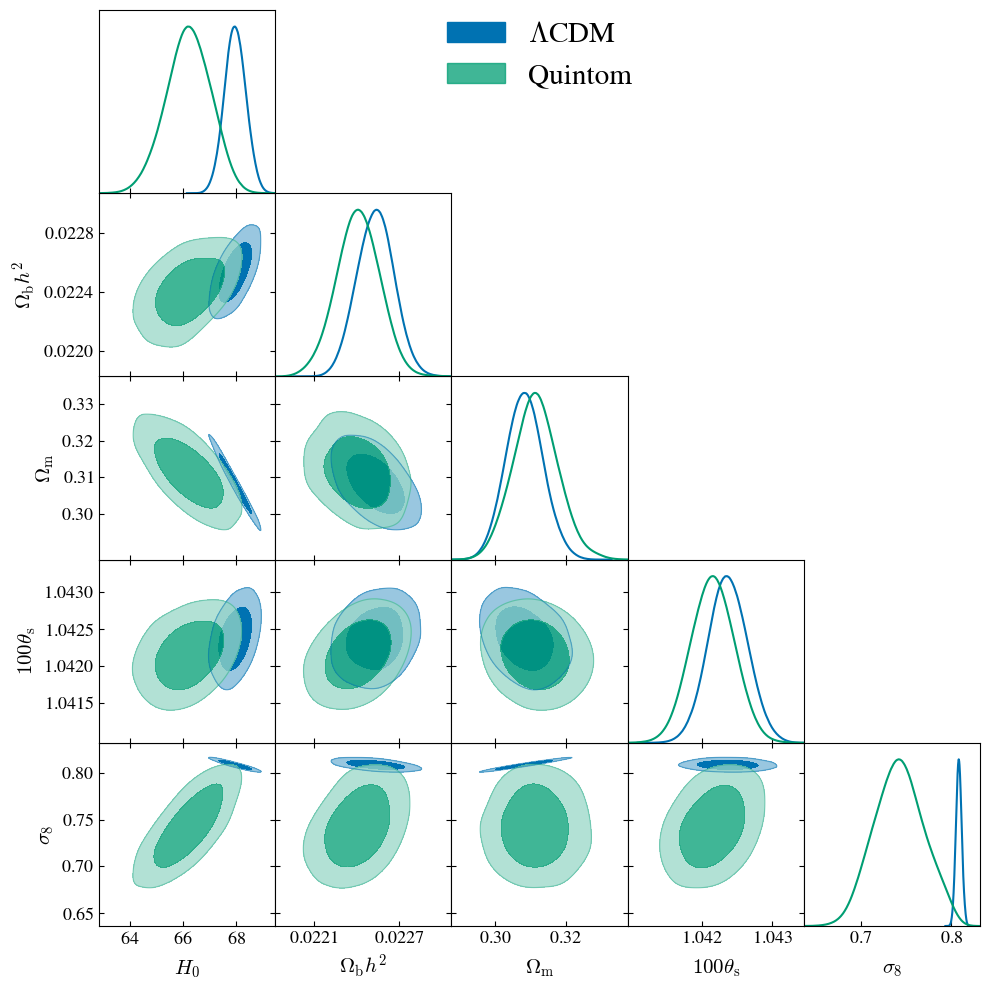

In [67]:
load_chains()
dataset_3 = ['lcdm_DESI+CMB+SNIa', 'quintom_DESI+CMB+SNIa']
lcdm_quintom_chains = {key: chains[key] for key in chains.keys() if key in dataset_3}

lcdm_quintom_plot = []
lcdm_quintom_plot = CobayaAnalyzer(chain_dicts=lcdm_quintom_chains, burn_in=0.3)
for _, [sample, _, _] in lcdm_quintom_plot.chains.items():
    p = sample.getParams()
    try:
        if not sample.paramNames.parWithName('abs_delta_qtm'):
            abs_delta_qtm = np.abs(p.delta_qtm)
            sample.addDerived(abs_delta_qtm, name='abs_delta_qtm', label=r'|\delta_{\mathrm{qtm}}|')
    except AttributeError:
        print(f"Parameter 'delta_qtm' not found in sample: {sample.getName()}")
        continue

lcdm_quintom_plot.plot_triangle(params=['H0', 'omega_b', 'Omega_m', 'theta_s_100', 'sigma8'],
                            fontsize=[16,18,24],
                            legend_labels=[r'$\Lambda$CDM', r'Quintom'],
                            colors=['#0072B2', '#009E73'],
                            save_as='quintom_2')